In [ ]:
pip install nixtla>=0.5.1

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('electricity.csv')
#df.rename(columns={'DATE': 'date', 'IPG2211A2N': 'power'}, inplace=True)
df.rename(columns={'DATE': 'date', 'Value': 'power'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%d-%m-/%Y')
#df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= '2015-12-31']
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Adjust 'D' for daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 50 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 500 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
print(mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"]))
print(mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"]))
print(mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"]))



ModuleNotFoundError: No module named 'nixtla'

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production.csv')
df.rename(columns={'DATE': 'date', 'Value': 'power'}, inplace=True)

# Fix date format
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

# Split the data
df_train = df[df['date'] <= '2015-12-31']
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing dates
df_train = df_train.set_index('date').asfreq('D')
df_train['power'] = df_train['power'].interpolate()
df_train.reset_index(inplace=True)

df_train = df_train.groupby('date', as_index=False).mean()

# Forecasts
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,
    time_col='date', target_col='power',
)

preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='power',
)

preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='power',
)

# Evaluation
print(mean_absolute_error(df_test['power'], preds_no_ft["TimeGPT"]))
print(mean_absolute_error(df_test['power'], preds_ft_25_steps["TimeGPT"]))
print(mean_absolute_error(df_test['power'], preds_ft_250_steps["TimeGPT"]))


ERROR:nixtla.nixtla_client:Attempt 1 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 2 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 3 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 4 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 5 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, e

ApiError: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}

In [ ]:
cd nixtla

[Errno 2] No such file or directory: 'nixtla'
/content


32 CONTEXT LENGTH

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production (1).csv')
df.rename(columns={'DATE': 'date', 'Value': 'IPG2211A2N'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= train_cutoff]
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Ensure daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# **Set context length to 32** by selecting the last 32 historical time steps
df_train = df_train.iloc[-128:]  # Use only the last 32 time steps

# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,  # Horizon remains 24
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 50 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 250 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
print(mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"]))
print(mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"]))
print(mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"]))


8.654147875000001
11.425073583333335
26.114825791666664


TIMEGPT_WITH PERPELEXITY

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Function to calculate perplexity
def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
    # Ensure arrays are numpy arrays for vectorized operations
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)

    # Normalize forecasts to ensure they sum to 1 across time steps
    normalized_forecasts = forecasts / (np.sum(forecasts) + epsilon)

    # Calculate negative log-likelihood
    nll = -np.sum(actuals * np.log(normalized_forecasts + epsilon))

    # Compute perplexity
    perplexity = np.exp(nll / np.prod(actuals.shape))
    return perplexity

def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
  # Calculate absolute differences between forecasts and actuals
    abs_diff = np.abs(np.array(forecasts) - np.array(actuals))

    # Identify hallucinations based on the threshold
    hallucinations = abs_diff > (threshold * np.mean(actuals))

    # Calculate hallucination rate
    hallucination_rate = np.sum(hallucinations) / len(hallucinations)

    return hallucination_rate

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production (1).csv')
df.rename(columns={'DATE': 'date', 'Value': 'IPG2211A2N'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
#df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= train_cutoff]
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Adjust 'D' for daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# **Set context length to 32** by selecting the last 32 historical time steps
df_train = df_train.iloc[-128:]  # Use only the last 32 time steps


# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 25 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 250 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
mae_no_ft = mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"])
mae_25_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"])
mae_250_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"])

# Evaluate forecast performance using Perplexity
perplexity_no_ft = calculate_perplexity(preds_no_ft["TimeGPT"], df_test['IPG2211A2N'])
perplexity_25_steps = calculate_perplexity(preds_ft_25_steps["TimeGPT"], df_test['IPG2211A2N'])
perplexity_250_steps = calculate_perplexity(preds_ft_250_steps["TimeGPT"], df_test['IPG2211A2N'])

# Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate
hallucination_rate_no_ft = calculate_hallucination_rate( preds_no_ft["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_25_steps = calculate_hallucination_rate(preds_ft_25_steps["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_250_steps = calculate_hallucination_rate(preds_ft_250_steps["TimeGPT"], df_test["IPG2211A2N"])

# Display results
print(f"MAE (No Fine-Tuning): {mae_no_ft}")
print(f"MAE (25 Fine-Tuning Steps): {mae_25_steps}")
print(f"MAE (250 Fine-Tuning Steps): {mae_250_steps}")
print(f"Perplexity (No Fine-Tuning): {perplexity_no_ft}")
print(f"Perplexity (25 Fine-Tuning Steps): {perplexity_25_steps}")
print(f"Perplexity (250 Fine-Tuning Steps): {perplexity_250_steps}")
print(f"Hallucination Rate (No Fine-Tuning): {hallucination_rate_no_ft}")
print(f"Hallucination Rate (25 Fine-Tuning Steps): {hallucination_rate_25_steps}")
print(f"Hallucination Rate (250 Fine-Tuning Steps): {hallucination_rate_250_steps}")


MAE (No Fine-Tuning): 8.654147875000001
MAE (25 Fine-Tuning Steps): 11.428727250000001
MAE (250 Fine-Tuning Steps): 25.908082500000006
Perplexity (No Fine-Tuning): 1.877066190014789e+141
Perplexity (25 Fine-Tuning Steps): 2.0322997758075415e+141
Perplexity (250 Fine-Tuning Steps): 4.3805441651786604e+141
Hallucination Rate (No Fine-Tuning): 0.4166666666666667
Hallucination Rate (25 Fine-Tuning Steps): 0.5416666666666666
Hallucination Rate (250 Fine-Tuning Steps): 0.7916666666666666


CONTEXT LENGTH 64

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Function to calculate perplexity
def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
    # Ensure arrays are numpy arrays for vectorized operations
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)

    # Normalize forecasts to ensure they sum to 1 across time steps
    normalized_forecasts = forecasts / (np.sum(forecasts) + epsilon)

    # Calculate negative log-likelihood
    nll = -np.sum(actuals * np.log(normalized_forecasts + epsilon))

    # Compute perplexity
    perplexity = np.exp(nll / np.prod(actuals.shape))
    return perplexity

def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
  # Calculate absolute differences between forecasts and actuals
    abs_diff = np.abs(np.array(forecasts) - np.array(actuals))

    # Identify hallucinations based on the threshold
    hallucinations = abs_diff > (threshold * np.mean(actuals))

    # Calculate hallucination rate
    hallucination_rate = np.sum(hallucinations) / len(hallucinations)

    return hallucination_rate

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production (1).csv')
df.rename(columns={'DATE': 'date', 'Value': 'IPG2211A2N'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
#df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= train_cutoff]
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Adjust 'D' for daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# **Set context length to 32** by selecting the last 32 historical time steps
df_train = df_train.iloc[-64:]  # Use only the last 32 time steps


# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 25 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 250 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
mae_no_ft = mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"])
mae_25_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"])
mae_250_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"])

# Evaluate forecast performance using Perplexity
perplexity_no_ft = calculate_perplexity(preds_no_ft["TimeGPT"], df_test['IPG2211A2N'])
perplexity_25_steps = calculate_perplexity(preds_ft_25_steps["TimeGPT"], df_test['IPG2211A2N'])
perplexity_250_steps = calculate_perplexity(preds_ft_250_steps["TimeGPT"], df_test['IPG2211A2N'])

# Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate
hallucination_rate_no_ft = calculate_hallucination_rate( preds_no_ft["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_25_steps = calculate_hallucination_rate(preds_ft_25_steps["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_250_steps = calculate_hallucination_rate(preds_ft_250_steps["TimeGPT"], df_test["IPG2211A2N"])

# Display results
print(f"MAE (No Fine-Tuning): {mae_no_ft}")
print(f"MAE (25 Fine-Tuning Steps): {mae_25_steps}")
print(f"MAE (250 Fine-Tuning Steps): {mae_250_steps}")
print(f"Perplexity (No Fine-Tuning): {perplexity_no_ft}")
print(f"Perplexity (25 Fine-Tuning Steps): {perplexity_25_steps}")
print(f"Perplexity (250 Fine-Tuning Steps): {perplexity_250_steps}")
print(f"Hallucination Rate (No Fine-Tuning): {hallucination_rate_no_ft}")
print(f"Hallucination Rate (25 Fine-Tuning Steps): {hallucination_rate_25_steps}")
print(f"Hallucination Rate (250 Fine-Tuning Steps): {hallucination_rate_250_steps}")


MAE (No Fine-Tuning): 8.654147875000001
MAE (25 Fine-Tuning Steps): 11.392761666666667
MAE (250 Fine-Tuning Steps): 25.2977515
Perplexity (No Fine-Tuning): 1.877066190014789e+141
Perplexity (25 Fine-Tuning Steps): 2.0224015043654268e+141
Perplexity (250 Fine-Tuning Steps): 3.8453241388670296e+141
Hallucination Rate (No Fine-Tuning): 0.4166666666666667
Hallucination Rate (25 Fine-Tuning Steps): 0.5
Hallucination Rate (250 Fine-Tuning Steps): 0.7916666666666666


CONTEXT LENGTH 96

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Function to calculate perplexity
def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
    # Ensure arrays are numpy arrays for vectorized operations
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)

    # Normalize forecasts to ensure they sum to 1 across time steps
    normalized_forecasts = forecasts / (np.sum(forecasts) + epsilon)

    # Calculate negative log-likelihood
    nll = -np.sum(actuals * np.log(normalized_forecasts + epsilon))

    # Compute perplexity
    perplexity = np.exp(nll / np.prod(actuals.shape))
    return perplexity

def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
  # Calculate absolute differences between forecasts and actuals
    abs_diff = np.abs(np.array(forecasts) - np.array(actuals))

    # Identify hallucinations based on the threshold
    hallucinations = abs_diff > (threshold * np.mean(actuals))

    # Calculate hallucination rate
    hallucination_rate = np.sum(hallucinations) / len(hallucinations)

    return hallucination_rate

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production (1).csv')
df.rename(columns={'DATE': 'date', 'Value': 'IPG2211A2N'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
#df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= train_cutoff]
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Adjust 'D' for daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# **Set context length to 32** by selecting the last 32 historical time steps
df_train = df_train.iloc[-96:]  # Use only the last 32 time steps


# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 25 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 250 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
mae_no_ft = mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"])
mae_25_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"])
mae_250_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"])

# Evaluate forecast performance using Perplexity
perplexity_no_ft = calculate_perplexity(preds_no_ft["TimeGPT"], df_test['IPG2211A2N'])
perplexity_25_steps = calculate_perplexity(preds_ft_25_steps["TimeGPT"], df_test['IPG2211A2N'])
perplexity_250_steps = calculate_perplexity(preds_ft_250_steps["TimeGPT"], df_test['IPG2211A2N'])

# Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate
hallucination_rate_no_ft = calculate_hallucination_rate( preds_no_ft["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_25_steps = calculate_hallucination_rate(preds_ft_25_steps["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_250_steps = calculate_hallucination_rate(preds_ft_250_steps["TimeGPT"], df_test["IPG2211A2N"])

# Display results
print(f"MAE (No Fine-Tuning): {mae_no_ft}")
print(f"MAE (25 Fine-Tuning Steps): {mae_25_steps}")
print(f"MAE (250 Fine-Tuning Steps): {mae_250_steps}")
print(f"Perplexity (No Fine-Tuning): {perplexity_no_ft}")
print(f"Perplexity (25 Fine-Tuning Steps): {perplexity_25_steps}")
print(f"Perplexity (250 Fine-Tuning Steps): {perplexity_250_steps}")
print(f"Hallucination Rate (No Fine-Tuning): {hallucination_rate_no_ft}")
print(f"Hallucination Rate (25 Fine-Tuning Steps): {hallucination_rate_25_steps}")
print(f"Hallucination Rate (250 Fine-Tuning Steps): {hallucination_rate_250_steps}")


MAE (No Fine-Tuning): 8.654148041666668
MAE (25 Fine-Tuning Steps): 11.386463916666665
MAE (250 Fine-Tuning Steps): 26.260609833333334
Perplexity (No Fine-Tuning): 1.8770661541884064e+141
Perplexity (25 Fine-Tuning Steps): 2.0248631892382415e+141
Perplexity (250 Fine-Tuning Steps): 4.001667772609899e+141
Hallucination Rate (No Fine-Tuning): 0.4166666666666667
Hallucination Rate (25 Fine-Tuning Steps): 0.5
Hallucination Rate (250 Fine-Tuning Steps): 0.8333333333333334


CONTEXT LENGTH 256

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Function to calculate perplexity
def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
    # Ensure arrays are numpy arrays for vectorized operations
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)

    # Normalize forecasts to ensure they sum to 1 across time steps
    normalized_forecasts = forecasts / (np.sum(forecasts) + epsilon)

    # Calculate negative log-likelihood
    nll = -np.sum(actuals * np.log(normalized_forecasts + epsilon))

    # Compute perplexity
    perplexity = np.exp(nll / np.prod(actuals.shape))
    return perplexity

def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
  # Calculate absolute differences between forecasts and actuals
    abs_diff = np.abs(np.array(forecasts) - np.array(actuals))

    # Identify hallucinations based on the threshold
    hallucinations = abs_diff > (threshold * np.mean(actuals))

    # Calculate hallucination rate
    hallucination_rate = np.sum(hallucinations) / len(hallucinations)

    return hallucination_rate

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production (1).csv')
df.rename(columns={'DATE': 'date', 'Value': 'IPG2211A2N'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
#df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= train_cutoff]
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Adjust 'D' for daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# **Set context length to 32** by selecting the last 32 historical time steps
df_train = df_train.iloc[-256:]  # Use only the last 32 time steps


# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=24,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 25 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 250 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=24, finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
mae_no_ft = mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"])
mae_25_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"])
mae_250_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"])

# Evaluate forecast performance using Perplexity
perplexity_no_ft = calculate_perplexity(preds_no_ft["TimeGPT"], df_test['IPG2211A2N'])
perplexity_25_steps = calculate_perplexity(preds_ft_25_steps["TimeGPT"], df_test['IPG2211A2N'])
perplexity_250_steps = calculate_perplexity(preds_ft_250_steps["TimeGPT"], df_test['IPG2211A2N'])

# Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate
hallucination_rate_no_ft = calculate_hallucination_rate( preds_no_ft["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_25_steps = calculate_hallucination_rate(preds_ft_25_steps["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_250_steps = calculate_hallucination_rate(preds_ft_250_steps["TimeGPT"], df_test["IPG2211A2N"])

# Display results
print(f"MAE (No Fine-Tuning): {mae_no_ft}")
print(f"MAE (25 Fine-Tuning Steps): {mae_25_steps}")
print(f"MAE (250 Fine-Tuning Steps): {mae_250_steps}")
print(f"Perplexity (No Fine-Tuning): {perplexity_no_ft}")
print(f"Perplexity (25 Fine-Tuning Steps): {perplexity_25_steps}")
print(f"Perplexity (250 Fine-Tuning Steps): {perplexity_250_steps}")
print(f"Hallucination Rate (No Fine-Tuning): {hallucination_rate_no_ft}")
print(f"Hallucination Rate (25 Fine-Tuning Steps): {hallucination_rate_25_steps}")
print(f"Hallucination Rate (250 Fine-Tuning Steps): {hallucination_rate_250_steps}")


MAE (No Fine-Tuning): 8.654147875000001
MAE (25 Fine-Tuning Steps): 9.523778
MAE (250 Fine-Tuning Steps): 9.833415875
Perplexity (No Fine-Tuning): 1.877066190014789e+141
Perplexity (25 Fine-Tuning Steps): 1.9194336866384552e+141
Perplexity (250 Fine-Tuning Steps): 1.9515688667800117e+141
Hallucination Rate (No Fine-Tuning): 0.4166666666666667
Hallucination Rate (25 Fine-Tuning Steps): 0.4166666666666667
Hallucination Rate (250 Fine-Tuning Steps): 0.4166666666666667


12 HOURS SAME CONTEXT

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Function to calculate perplexity
def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
    # Ensure arrays are numpy arrays for vectorized operations
    forecasts = np.array(forecasts)
    actuals = np.array(actuals)

    # Normalize forecasts to ensure they sum to 1 across time steps
    normalized_forecasts = forecasts / (np.sum(forecasts) + epsilon)

    # Calculate negative log-likelihood
    nll = -np.sum(actuals * np.log(normalized_forecasts + epsilon))

    # Compute perplexity
    perplexity = np.exp(nll / np.prod(actuals.shape))
    return perplexity

def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
  # Calculate absolute differences between forecasts and actuals
    abs_diff = np.abs(np.array(forecasts) - np.array(actuals))

    # Identify hallucinations based on the threshold
    hallucinations = abs_diff > (threshold * np.mean(actuals))

    # Calculate hallucination rate
    hallucination_rate = np.sum(hallucinations) / len(hallucinations)

    return hallucination_rate

# Load the dataset containing electric production data and pre-process data
df = pd.read_csv('Electric_Production (1).csv')
df.rename(columns={'DATE': 'date', 'Value': 'IPG2211A2N'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
#df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Split the data into training and testing sets
train_cutoff = '2015-12-31'
df_train = df[df['date'] <= train_cutoff]
df_test = df[df['date'].between('2016-01-01', '2017-12-31')]

# Handle missing or irregular intervals
df_train = df_train.set_index('date').asfreq('D')  # Adjust 'D' for daily frequency
df_train['IPG2211A2N'] = df_train['IPG2211A2N'].interpolate()  # Interpolate missing values
df_train.reset_index(inplace=True)

# Ensure no duplicates
df_train = df_train.groupby('date', as_index=False).mean()

# **Set context length to 32** by selecting the last 32 historical time steps
df_train = df_train.iloc[-256:]  # Use only the last 32 time steps


# Generate forecasts without fine-tuning (baseline)
preds_no_ft = nixtla_client.forecast(
    df=df_train, h=len(df_test),
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 25 fine-tuning steps
preds_ft_25_steps = nixtla_client.forecast(
    df=df_train, h=len(df_test), finetune_steps=25,
    time_col='date', target_col='IPG2211A2N',
)

# Generate forecasts with 250 fine-tuning steps
preds_ft_250_steps = nixtla_client.forecast(
    df=df_train, h=len(df_test), finetune_steps=250,
    time_col='date', target_col='IPG2211A2N',
)

# Evaluate forecast performance using Mean Absolute Error (MAE)
mae_no_ft = mean_absolute_error(df_test['IPG2211A2N'], preds_no_ft["TimeGPT"])
mae_25_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_25_steps["TimeGPT"])
mae_250_steps = mean_absolute_error(df_test['IPG2211A2N'], preds_ft_250_steps["TimeGPT"])

# Evaluate forecast performance using Perplexity
perplexity_no_ft = calculate_perplexity(preds_no_ft["TimeGPT"], df_test['IPG2211A2N'])
perplexity_25_steps = calculate_perplexity(preds_ft_25_steps["TimeGPT"], df_test['IPG2211A2N'])
perplexity_250_steps = calculate_perplexity(preds_ft_250_steps["TimeGPT"], df_test['IPG2211A2N'])

# Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate
hallucination_rate_no_ft = calculate_hallucination_rate( preds_no_ft["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_25_steps = calculate_hallucination_rate(preds_ft_25_steps["TimeGPT"], df_test["IPG2211A2N"])
hallucination_rate_250_steps = calculate_hallucination_rate(preds_ft_250_steps["TimeGPT"], df_test["IPG2211A2N"])

# Display results
print(f"MAE (No Fine-Tuning): {mae_no_ft}")
print(f"MAE (25 Fine-Tuning Steps): {mae_25_steps}")
print(f"MAE (250 Fine-Tuning Steps): {mae_250_steps}")
print(f"Perplexity (No Fine-Tuning): {perplexity_no_ft}")
print(f"Perplexity (25 Fine-Tuning Steps): {perplexity_25_steps}")
print(f"Perplexity (250 Fine-Tuning Steps): {perplexity_250_steps}")
print(f"Hallucination Rate (No Fine-Tuning): {hallucination_rate_no_ft}")
print(f"Hallucination Rate (25 Fine-Tuning Steps): {hallucination_rate_25_steps}")
print(f"Hallucination Rate (250 Fine-Tuning Steps): {hallucination_rate_250_steps}")


MAE (No Fine-Tuning): 8.654148041666668
MAE (25 Fine-Tuning Steps): 9.523778
MAE (250 Fine-Tuning Steps): 9.833415875
Perplexity (No Fine-Tuning): 1.8770661541884064e+141
Perplexity (25 Fine-Tuning Steps): 1.9194336866384552e+141
Perplexity (250 Fine-Tuning Steps): 1.9515688667800117e+141
Hallucination Rate (No Fine-Tuning): 0.4166666666666667
Hallucination Rate (25 Fine-Tuning Steps): 0.4166666666666667
Hallucination Rate (250 Fine-Tuning Steps): 0.4166666666666667


Time-GPT with Oil and Gas Dataset

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())
# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
          abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
          hallucinations = abs_diff > (threshold * np.mean(actuals))
          hallucination_rate = np.sum(hallucinations) / len(hallucinations)
          return hallucination_rate
          # Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate

        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)


        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)


    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")

        # Display results


<ipython-input-8-c10493001054>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-8-c10493001054>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-8-c10493001054>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-8-c10493001054>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future ve

   timestamp  target_WS  target_RH  target_T item_id
0 2000-11-02       4.94      87.44     27.05       A
1 2000-11-03       4.50      86.19     27.14       A
2 2000-11-04       2.77      83.38     27.26       A
3 2000-11-05       2.00      81.00     27.08       A
4 2000-11-06       2.53      80.44     27.49       A
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

CONTEX LENGTH 32

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# **Set context length to 32** by selecting the last 32 historical time steps
#df_train = df_train.iloc[-256:]  # Use only the last 32 time steps


# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())
# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
          abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
          hallucinations = abs_diff > (threshold * np.mean(actuals))
          hallucination_rate = np.sum(hallucinations) / len(hallucinations)
          return hallucination_rate
          # Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate

        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)


        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)


    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")

        # Display results


<ipython-input-12-0b770c3985b7>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-12-0b770c3985b7>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-12-0b770c3985b7>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-12-0b770c3985b7>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a futur

      timestamp  target_WS  target_RH  target_T item_id
5585 2019-10-09       1.07      72.62     28.13       T
5586 2019-10-10       1.55      74.62     28.22       T
5587 2019-10-11       0.90      74.12     28.10       T
5588 2019-10-12       1.30      72.25     28.62       T
5589 2019-10-13       1.98      74.88     28.67       T
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


ValueError: Some series are too short. Please make sure that each serie contains at least 35 observations.

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# Instead of reducing the context length for all data,
# filter df_train to ensure each item_id has at least 35 observations:
df_train = df_train.groupby('item_id').filter(lambda x: len(x) >= 35)

# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())
# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
          abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
          hallucinations = abs_diff > (threshold * np.mean(actuals))
          hallucination_rate = np.sum(hallucinations) / len(hallucinations)
          return hallucination_rate
          # Evaluate forecast performance using Mean Absolute Error (MAE) and Hallucination Rate

        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)


        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)


    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")

        # Display results

<ipython-input-13-432be96fd70c>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-13-432be96fd70c>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-13-432be96fd70c>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-13-432be96fd70c>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a futur

   timestamp  target_WS  target_RH  target_T item_id
0 2000-11-02       4.94      87.44     27.05       A
1 2000-11-03       4.50      86.19     27.14       A
2 2000-11-04       2.77      83.38     27.26       A
3 2000-11-05       2.00      81.00     27.08       A
4 2000-11-06       2.53      80.44     27.49       A
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# **Incorporate context length of 128:**
def apply_context_length(group):
    return group.iloc[-128:]  # Select the last 128 observations

df_train = df_train.groupby('item_id', group_keys=False).apply(apply_context_length).reset_index(drop=True)

# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())

# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
            abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
            hallucinations = abs_diff > (threshold * np.mean(actuals))
            hallucination_rate = np.sum(hallucinations) / len(hallucinations)
            return hallucination_rate

        # Evaluate forecast performance
        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)

        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)

    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")


<ipython-input-17-5bb11252135f>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-17-5bb11252135f>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-17-5bb11252135f>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-17-5bb11252135f>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a futur

   timestamp  target_WS  target_RH  target_T item_id
0 2000-11-02       4.94      87.44     27.05       A
1 2000-11-03       4.50      86.19     27.14       A
2 2000-11-04       2.77      83.38     27.26       A
3 2000-11-05       2.00      81.00     27.08       A
4 2000-11-06       2.53      80.44     27.49       A
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# **Incorporate context length of 128:**
def apply_context_length(group):
    return group.iloc[-64:]  # Select the last 128 observations

df_train = df_train.groupby('item_id', group_keys=False).apply(apply_context_length).reset_index(drop=True)

# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())

# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
            abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
            hallucinations = abs_diff > (threshold * np.mean(actuals))
            hallucination_rate = np.sum(hallucinations) / len(hallucinations)
            return hallucination_rate

        # Evaluate forecast performance
        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)

        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)

    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")


<ipython-input-18-5bc36b03c1f3>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-18-5bc36b03c1f3>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-18-5bc36b03c1f3>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-18-5bc36b03c1f3>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a futur

   timestamp  target_WS  target_RH  target_T item_id
0 2000-11-02       4.94      87.44     27.05       A
1 2000-11-03       4.50      86.19     27.14       A
2 2000-11-04       2.77      83.38     27.26       A
3 2000-11-05       2.00      81.00     27.08       A
4 2000-11-06       2.53      80.44     27.49       A
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# **Incorporate context length of 128:**
def apply_context_length(group):
    return group.iloc[-96:]  # Select the last 128 observations

df_train = df_train.groupby('item_id', group_keys=False).apply(apply_context_length).reset_index(drop=True)

# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())

# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
            abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
            hallucinations = abs_diff > (threshold * np.mean(actuals))
            hallucination_rate = np.sum(hallucinations) / len(hallucinations)
            return hallucination_rate

        # Evaluate forecast performance
        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)

        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)

    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")


<ipython-input-19-6cc1564b6e04>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-19-6cc1564b6e04>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-19-6cc1564b6e04>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-19-6cc1564b6e04>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a futur

   timestamp  target_WS  target_RH  target_T item_id
0 2000-11-02       4.94      87.44     27.05       A
1 2000-11-03       4.50      86.19     27.14       A
2 2000-11-04       2.77      83.38     27.26       A
3 2000-11-05       2.00      81.00     27.08       A
4 2000-11-06       2.53      80.44     27.49       A
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

In [ ]:
from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Initialize the TimeGPT client with your API key
nixtla_client = NixtlaClient(api_key='nixak-7RReF6lUGkoUEZ70JafiH9O7FmixtQXfRueIP4tOzE13zE2PvAswxA4LfkgMniu3Hhyjae9uWWS2NXt3')

# Load the multivariate dataset
df = pd.read_csv('timeseries.csv')

# Preprocessing
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y')
df.sort_values(by=['item_id', 'timestamp'], inplace=True)

# Ensure no missing values or irregular intervals
def preprocess_item(df_item):
    df_item = df_item.set_index('timestamp').asfreq('D')  # Resample to daily frequency
    df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
    return df_item

df = df.groupby('item_id', group_keys=False).apply(preprocess_item).reset_index()

# Split data into train (80%) and test (20%)
train_ratio = 0.8
def train_test_split(group):
    split_idx = int(len(group) * train_ratio)
    return group.iloc[:split_idx], group.iloc[split_idx:]

df_train, df_test = zip(*[train_test_split(group) for _, group in df.groupby('item_id')])
df_train = pd.concat(df_train).reset_index(drop=True)
df_test = pd.concat(df_test).reset_index(drop=True)

# **Incorporate context length of 128:**
def apply_context_length(group):
    return group.iloc[-256:]  # Select the last 128 observations

df_train = df_train.groupby('item_id', group_keys=False).apply(apply_context_length).reset_index(drop=True)

# Debugging: Inspect the train and test datasets
print(df_train.head())
print(df_test.head())

# Generate forecasts and evaluate metrics for each target variable
metrics = {}
for target in ['target_WS', 'target_RH', 'target_T']:
    print(f"Processing target: {target}")

    # Prepare test data grouped by item_id
    test_groups = df_test.groupby('item_id')

    # Generate forecasts
    preds_no_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id'
    )

    preds_ft = nixtla_client.forecast(
        df=df_train[['timestamp', target, 'item_id']], h=len(test_groups),
        time_col='timestamp', target_col=target, id_col='item_id',
        finetune_steps=50
    )

    # Initialize metrics for this target
    target_metrics = {'MAE_no_ft': [], 'MAE_ft': [], 'Perplexity_no_ft': [], 'Perplexity_ft': [], 'hallucination_rate_no_ft': [], 'hallucination_rate_ft': []}

    # Evaluate per item_id
    for item_id, group in test_groups:
        print(f"  Evaluating item_id: {item_id}")

        # Extract actual values for this item_id
        y_true = group[target].values

        # Extract predictions for this item_id
        pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
        pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

        # Ensure consistent lengths
        if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
            print(f"  Skipping item_id {item_id} due to length mismatch.")
            continue

        # Calculate MAE
        mae_no_ft = mean_absolute_error(y_true, pred_no_ft)
        mae_ft = mean_absolute_error(y_true, pred_ft)

        # Calculate Perplexity
        def calculate_perplexity(forecasts, actuals, epsilon=1e-8):
            nll = -np.sum(actuals * np.log(forecasts + epsilon))
            perplexity = np.exp(nll / len(actuals))
            return perplexity

        perplexity_no_ft = calculate_perplexity(pred_no_ft, y_true)
        perplexity_ft = calculate_perplexity(pred_ft, y_true)

        def calculate_hallucination_rate(forecasts, actuals, threshold=0.1):
            abs_diff = np.abs(np.array(forecasts) - np.array(actuals))
            hallucinations = abs_diff > (threshold * np.mean(actuals))
            hallucination_rate = np.sum(hallucinations) / len(hallucinations)
            return hallucination_rate

        # Evaluate forecast performance
        hallucination_rate_no_ft = calculate_hallucination_rate(pred_no_ft, y_true)
        hallucination_rate_ft = calculate_hallucination_rate(pred_ft, y_true)

        # Append metrics
        target_metrics['MAE_no_ft'].append(mae_no_ft)
        target_metrics['MAE_ft'].append(mae_ft)
        target_metrics['Perplexity_no_ft'].append(perplexity_no_ft)
        target_metrics['Perplexity_ft'].append(perplexity_ft)
        target_metrics['hallucination_rate_no_ft'].append(hallucination_rate_no_ft)
        target_metrics['hallucination_rate_ft'].append(hallucination_rate_ft)

    # Average metrics across all item_ids for this target
    metrics[target] = {metric: np.mean(values) for metric, values in target_metrics.items()}

# Display final metrics
for target, target_metrics in metrics.items():
    print(f"\nMetrics for {target}:")
    for metric_name, value in target_metrics.items():
        print(f"  {metric_name}: {value}")


<ipython-input-20-273f59a2ffb9>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-20-273f59a2ffb9>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-20-273f59a2ffb9>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_item.interpolate(method='linear', inplace=True)   # Interpolate missing values
<ipython-input-20-273f59a2ffb9>:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a futur

   timestamp  target_WS  target_RH  target_T item_id
0 2000-11-02       4.94      87.44     27.05       A
1 2000-11-03       4.50      86.19     27.14       A
2 2000-11-04       2.77      83.38     27.26       A
3 2000-11-05       2.00      81.00     27.08       A
4 2000-11-06       2.53      80.44     27.49       A
   timestamp  target_WS  target_RH  target_T item_id
0 2000-12-20       1.41      86.75     26.19       A
1 2000-12-21       4.88      88.62     26.53       A
2 2000-12-22       7.52      87.94     26.87       A
3 2000-12-23       8.70      86.25     26.81       A
4 2000-12-24       7.88      84.19     26.76       A
Processing target: target_WS


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

ERROR:nixtla.nixtla_client:Attempt 1 failed with error: status_code: 502, body: Could not parse JSON: b'Missing request, possibly due to expiry or cancellation'


  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

  Evaluating item_id: A
  Evaluating item_id: B
  Skipping item_id B due to length mismatch.
  Evaluating item_id: C
  Skipping item_id C due to length mismatch.
  Evaluating item_id: D
  Skipping item_id D due to length mismatch.
  Evaluating item_id: E
  Skipping item_id E due to length mismatch.
  Evaluating item_id: F
  Skipping item_id F due to length mismatch.
  Evaluating item_id: G
  Skipping item_id G due to length mismatch.
  Evaluating item_id: H
  Skipping item_id H due to length mismatch.
  Evaluating item_id: I
  Skipping item_id I due to length mismatch.
  Evaluating item_id: J
  Skipping item_id J due to length mismatch.
  Evaluating item_id: K
  Skipping item_id K due to length mismatch.
  Evaluating item_id: L
  Skipping item_id L due to length mismatch.
  Evaluating item_id: M
  Skipping item_id M due to length mismatch.
  Evaluating item_id: N
  Skipping item_id N due to length mismatch.
  Evaluating item_id: O
  Skipping item_id O due to length mismatch.
  Evaluati

In [ ]:
df_train.head()

,timestamp,target_WS,target_RH,target_T,item_id
0,2000-11-02,4.94,87.44,27.05,A
1,2000-11-03,4.50,86.19,27.14,A
2,2000-11-04,2.77,83.38,27.26,A
3,2000-11-05,2.00,81.00,27.08,A
4,2000-11-06,2.53,80.44,27.49,A


In [ ]:
df_test.head()

,timestamp,target_WS,target_RH,target_T,item_id
0,2000-12-20,1.41,86.75,26.19,A
1,2000-12-21,4.88,88.62,26.53,A
2,2000-12-22,7.52,87.94,26.87,A
3,2000-12-23,8.70,86.25,26.81,A
4,2000-12-24,7.88,84.19,26.76,A


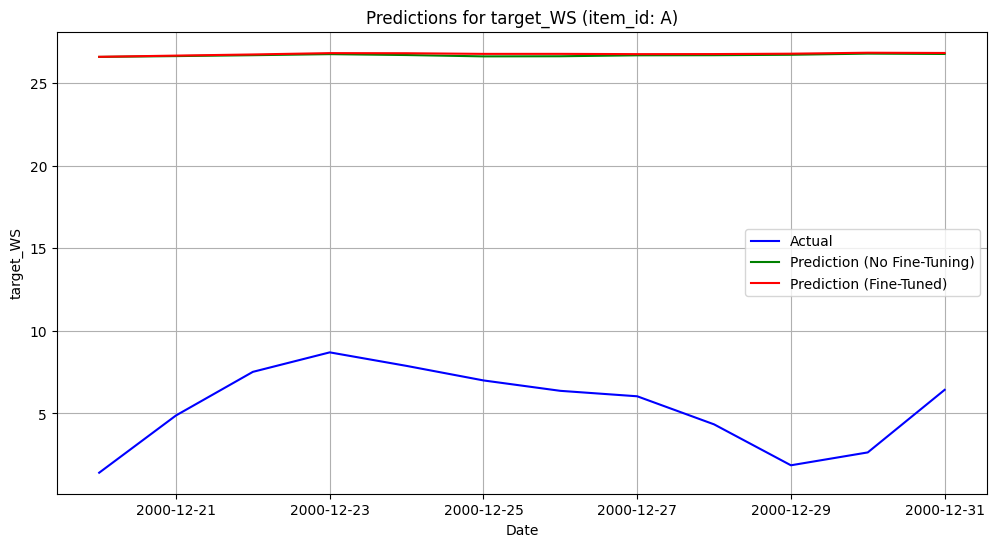

Skipping item_id B due to length mismatch.
Skipping item_id C due to length mismatch.


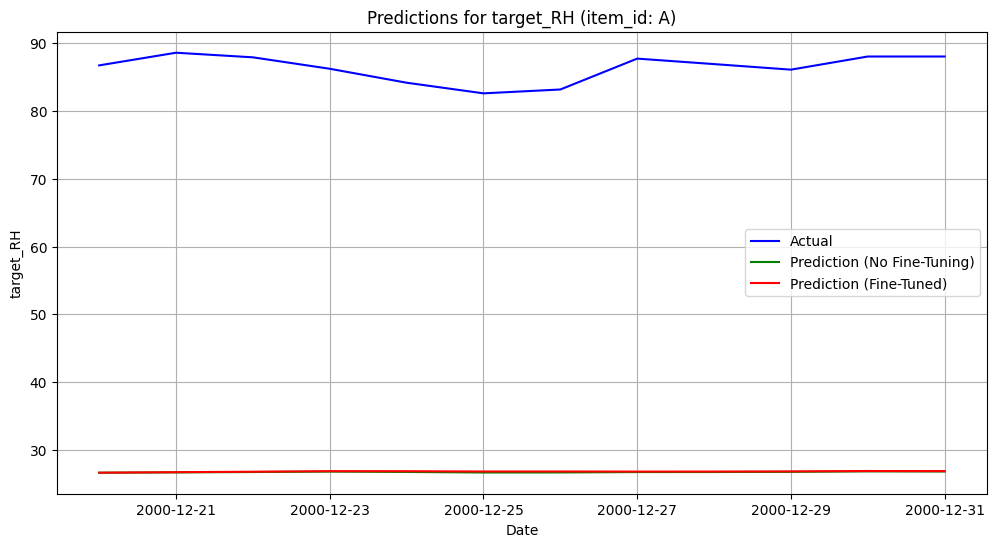

Skipping item_id B due to length mismatch.
Skipping item_id C due to length mismatch.


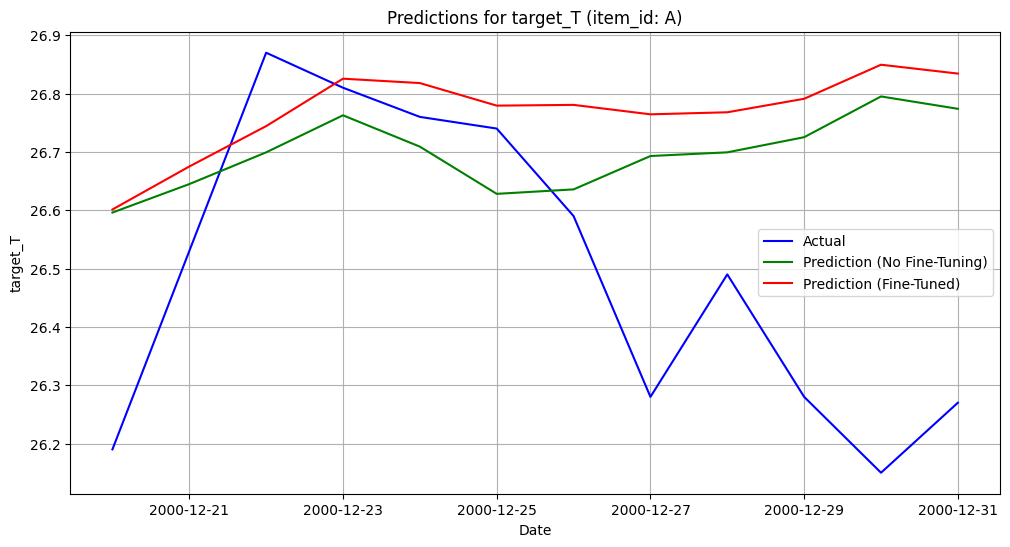

Skipping item_id B due to length mismatch.
Skipping item_id C due to length mismatch.


In [ ]:
import matplotlib.pyplot as plt

# Function to plot predictions and actual values
def plot_predictions(df_test, preds_no_ft, preds_ft, target, item_id):
    # Filter test data for the specific item_id
    test_data = df_test[df_test['item_id'] == item_id]
    y_true = test_data[target].values

    # Extract predictions for the specific item_id
    pred_no_ft = preds_no_ft[preds_no_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]
    pred_ft = preds_ft[preds_ft['item_id'] == item_id]['TimeGPT'].values[:len(y_true)]

    # Ensure consistent lengths
    if len(pred_no_ft) != len(y_true) or len(pred_ft) != len(y_true):
        print(f"Skipping item_id {item_id} due to length mismatch.")
        return

    # Plot the actual and predicted values
    plt.figure(figsize=(12, 6))
    plt.plot(test_data['timestamp'], y_true, label='Actual', color='blue')
    plt.plot(test_data['timestamp'], pred_no_ft, label='Prediction (No Fine-Tuning)', color='green')
    plt.plot(test_data['timestamp'], pred_ft, label='Prediction (Fine-Tuned)', color='red')

    # Add labels, title, and legend
    plt.xlabel('Date')
    plt.ylabel(target)
    plt.title(f'Predictions for {target} (item_id: {item_id})')
    plt.legend()
    plt.grid()
    plt.show()

# Example: Visualize predictions for a specific target and item_id
for target in ['target_WS', 'target_RH', 'target_T']:
    for item_id in df_test['item_id'].unique()[:3]:  # Visualize for first 3 item_ids
        plot_predictions(df_test, preds_no_ft, preds_ft, target, item_id)


In [ ]:
df

,timestamp,target_WS,target_RH,target_T,item_id
0,2000-11-02,4.94,87.44,27.05,A
1,2000-11-03,4.50,86.19,27.14,A
2,2000-11-04,2.77,83.38,27.26,A
3,2000-11-05,2.00,81.00,27.08,A
4,2000-11-06,2.53,80.44,27.49,A
...,...,...,...,...,...
7301,2020-10-29,3.62,81.75,28.45,U
7302,2020-10-30,2.07,81.69,27.97,U
7303,2020-10-31,3.03,81.12,28.37,U
7304,2020-11-01,3.85,82.06,28.17,U


In [ ]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('timeseries.csv', skip_blank_lines=True)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
timestamp    0
target_WS    0
target_RH    0
target_T     0
item_id      0
dtype: int64
